In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
all_dat = pd.read_csv('/content/HRDataset_v14.csv')
all_dat

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


Data Organization/Cleaning

In [102]:
#excluding specific termination reasons that the company cannot control
all_dat['TermReason'].unique()
excluded_reasons = ['return to school', 'Learned that he is a gangster', 'military', 'relocation out of area', 'retiring']
dat = all_dat[all_dat['TermReason'].isin(excluded_reasons) == False]

#creating useful subdatasets for efficiency
cur_emp = dat[dat['Termd'] == 0]
ex_emp = dat[dat['Termd'] == 1]

#manager id column had null values for manager named webster
#entering a managerid for the null values
dat.loc[(dat['ManagerName'] == 'Webster Butler') & (dat['ManagerID'].isnull()), 'ManagerID'] = 39

#making a new column for employee status so graphs are easier to understand
dat['EmployeeStatus'] = 'Terminated Employees'
dat.loc[dat['Termd'] == 0, 'EmployeeStatus'] = 'Current Employees'

<ipython-input-102-2833973ce119>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['EmployeeStatus'] = 'Terminated Employees'


Summary Statistics

In [67]:
#counting number of managers
dat['ManagerID'].nunique() #22
dat.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,10155.273973,0.410959,0.815068,0.431507,2.226027,4.589041,2.976027,0.089041,69504.452055,0.291096,16.712329,6710.821918,14.708904,4.099623,3.890411,1.273973,0.431507,10.198630
std,90.494595,0.492852,0.934291,0.496137,1.724178,1.107123,0.600207,0.285292,25674.981055,0.455047,6.297285,17325.455583,8.334555,0.798754,0.920356,2.381257,1.323369,5.841691
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10077.750000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55713.500000,0.000000,16.750000,1889.250000,10.000000,3.682500,3.000000,0.000000,0.000000,5.000000
50%,10154.500000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62860.000000,0.000000,19.000000,2132.000000,15.000000,4.245000,4.000000,0.000000,0.000000,10.000000
75%,10233.250000,1.000000,1.000000,1.000000,4.000000,5.000000,3.000000,0.000000,72497.250000,1.000000,20.000000,2359.250000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,29.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


Salary and Attrition

TtestResult(statistic=1.236647457644804, pvalue=0.21721855274223148, df=290.0)

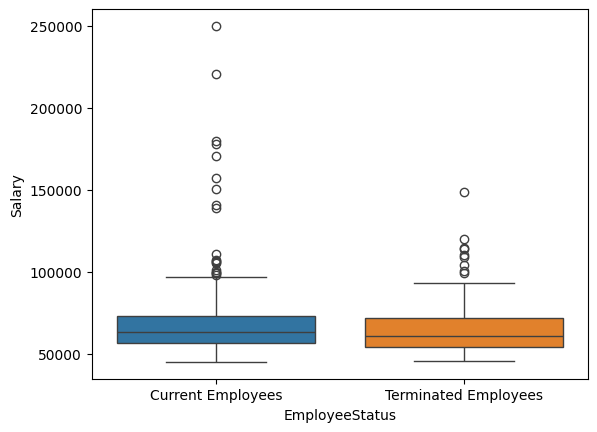

In [104]:
sns.boxplot(dat, x="EmployeeStatus", y="Salary", hue='EmployeeStatus')

ex_emp['Salary'].mean() # $66607.47
cur_emp['Salary'].mean() # $70694.03

stats.ttest_ind(cur_emp['Salary'], ex_emp['Salary'])

<Axes: xlabel='Department', ylabel='Salary'>

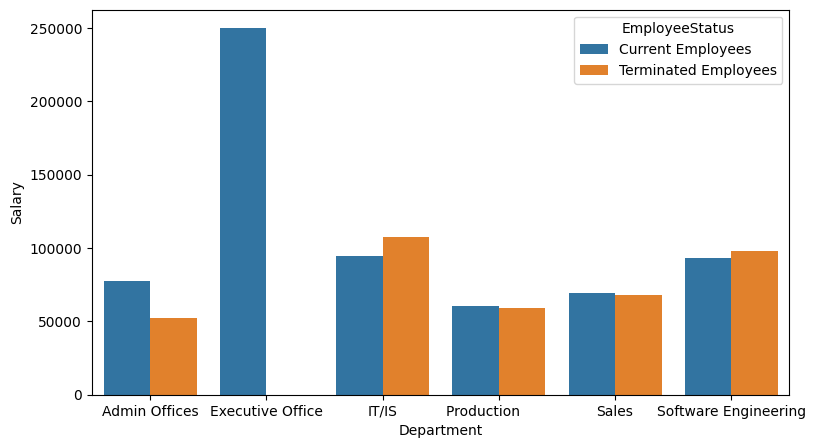

In [167]:
#does salary by department give different results
plt.figure(figsize=(9, 5))
sal_by_dept = dat.groupby(['Department', 'EmployeeStatus'])['Salary'].mean().reset_index()
sns.barplot(sal_by_dept, x='Department', y='Salary', hue='EmployeeStatus')

Text(0, 0.5, 'Termination Rate')

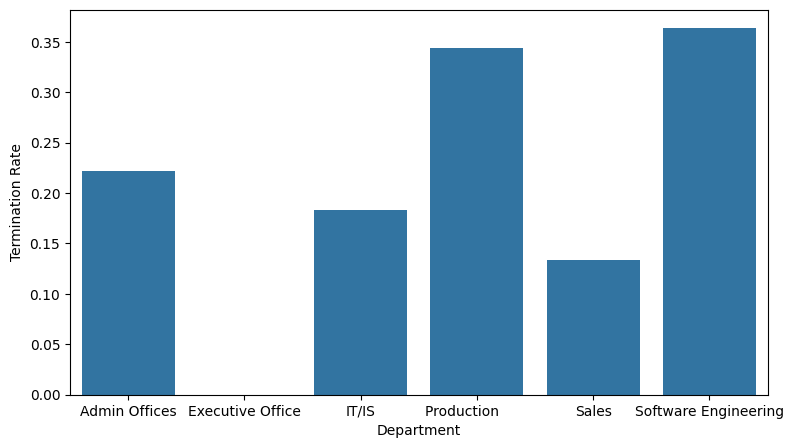

In [109]:
#is term rate different for admin offices or IT/IS because of the differing salaries
plt.figure(figsize=(9, 5))
attrition_by_department = dat.groupby('Department')['Termd'].mean().reset_index()
sns.barplot(attrition_by_department, x='Department', y='Termd')
plt.ylabel("Termination Rate")

In [137]:
#why are employees leaving the software engineering department
ex_emp[ex_emp['Department'] == 'Software Engineering']['TermReason']

,TermReason
86,attendance
212,Another position
227,career change
285,medical issues


Performance Score by Department

<Axes: xlabel='Department', ylabel='PerfScoreID'>

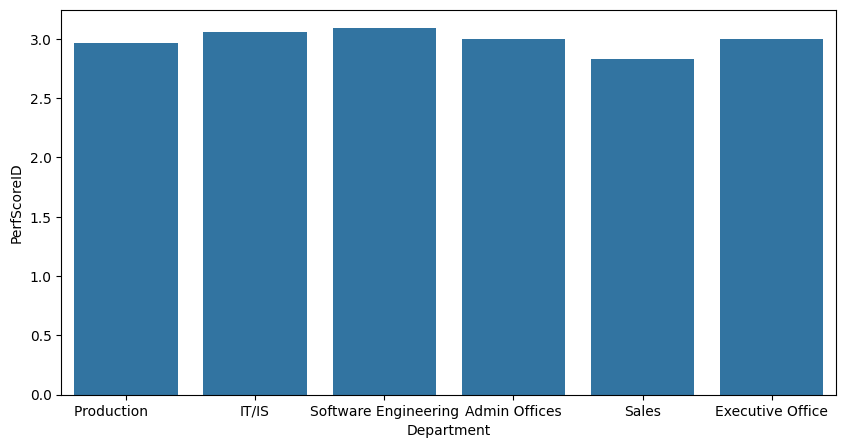

In [144]:
#do some departments perform better than others
plt.figure(figsize=(10, 5))
sns.barplot(dat, x='Department', y='PerfScoreID', errorbar=None)

Job satisfaction and attrition

<Axes: xlabel='EmployeeStatus', ylabel='EmpSatisfaction'>

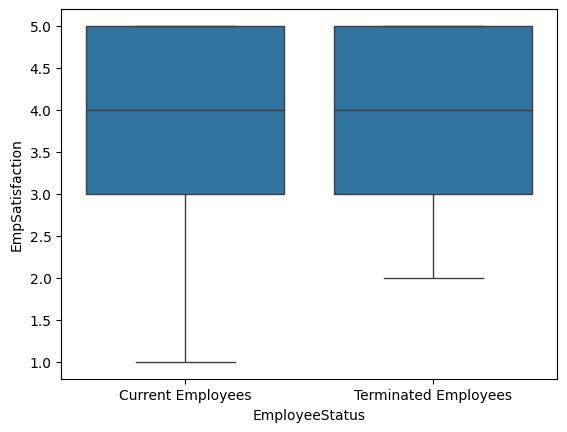

In [128]:
#are terminated employees less satisfied with their job
cur_emp['EmpSatisfaction'].mean() #3.89
ex_emp['EmpSatisfaction'].mean() #3.88

sns.boxplot(dat, x="EmployeeStatus", y="EmpSatisfaction")

Performance score and attrition

4.11

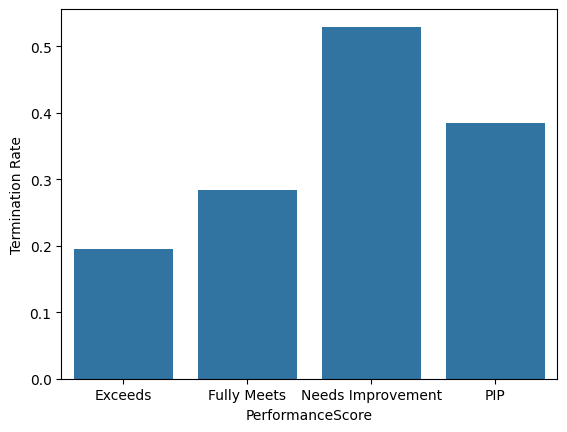

In [145]:
#does employee performance relate with termination rate
sns.barplot(dat, x='PerformanceScore', y='Termd', errorbar=None)
plt.ylabel("Termination Rate")

Engagement Survey

Text(0.5, 0, 'Performace Score')

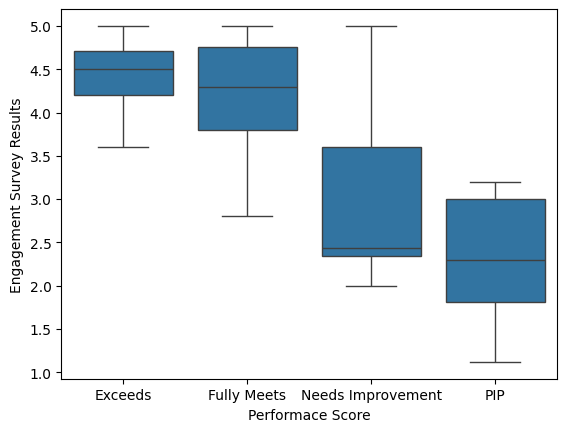

In [147]:
#does exmployee engagement relate with performance
sns.boxplot(dat, x='PerformanceScore', y='EngagementSurvey')
plt.ylabel("Engagement Survey Results")
plt.xlabel("Performace Score")

Managers

Text(0, 0.5, 'Manager Name')

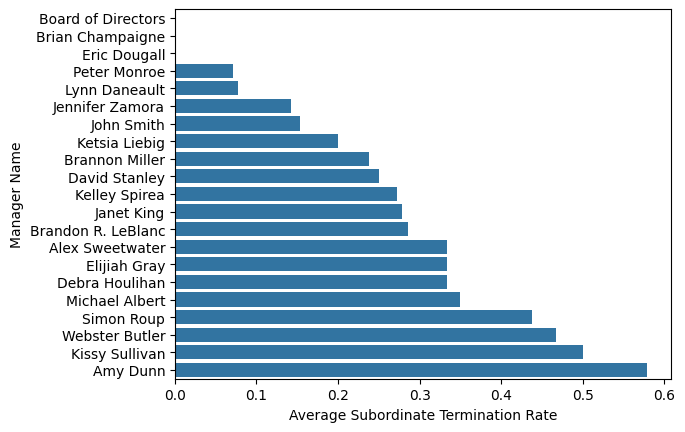

In [159]:
#do certain managers have worse termination rates than others
term_rate_by_mngr = dat.groupby('ManagerName')['Termd'].mean().reset_index()

term_rate_by_mngr = term_rate_by_mngr.sort_values(by='Termd')
sns.barplot(term_rate_by_mngr, x='Termd', y='ManagerName')

plt.xlabel("Average Subordinate Termination Rate")
plt.ylabel("Manager Name")



Text(0, 0.5, 'Manager Name')

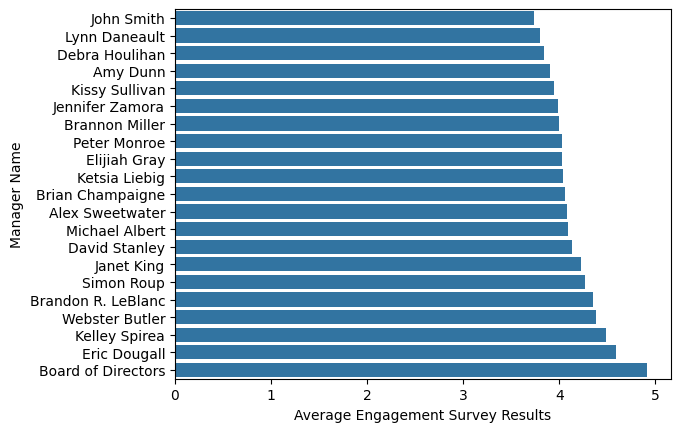

In [158]:
#do certain managers have worse engagement survey averages than others
mngr_engage_surv = dat.groupby('ManagerName')['EngagementSurvey'].mean().reset_index()

mngr_engage_surv = mngr_engage_surv.sort_values(by='EngagementSurvey')
sns.barplot(mngr_engage_surv, x='EngagementSurvey', y='ManagerName')

plt.xlabel("Average Engagement Survey Results")
plt.ylabel("Manager Name")